In [13]:
# Install required packages.
import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

2.6.0+cu124
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [14]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GINConv, global_mean_pool
from torch_geometric.utils import to_dense_adj
import numpy as np
import matplotlib.pyplot as plt

In [15]:
# Load dataset
dataset = TUDataset(root='data', name='MUTAG')
print(f"Graphs: {len(dataset)}, Classes: {dataset.num_classes}, Node features: {dataset.num_node_features}")

Graphs: 188, Classes: 2, Node features: 7


In [16]:
# 1-step Laplacian smoothing
def smooth_features_once(data):
    num_nodes = data.num_nodes
    A = to_dense_adj(data.edge_index, max_num_nodes=num_nodes)[0]
    I = torch.eye(num_nodes)
    A_hat = A + I
    deg = A_hat.sum(dim=1)
    D_inv = torch.diag(1.0 / deg)
    data_sm = data.clone()
    data_sm.x = D_inv @ (A_hat @ data.x.float())
    return data_sm

smoothed_dataset = [smooth_features_once(data) for data in dataset]

In [18]:
# Models, GCN and GIN
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin = torch.nn.Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x)

class GIN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes):
        super().__init__()
        nn1 = torch.nn.Sequential(
            torch.nn.Linear(in_channels, hidden_channels),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_channels, hidden_channels)
        )
        self.conv1 = GINConv(nn1)
        nn2 = torch.nn.Sequential(
            torch.nn.Linear(hidden_channels, hidden_channels),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_channels, hidden_channels)
        )
        self.conv2 = GINConv(nn2)
        self.lin = torch.nn.Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x)

In [19]:
# Training and evaluation
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        out = model(batch.x.float(), batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    for batch in loader:
        out = model(batch.x.float(), batch.edge_index, batch.batch)
        pred = out.argmax(dim=1)
        correct += (pred == batch.y).sum().item()
        total += batch.y.size(0)
    return correct / total

In [25]:
def run_single_experiment(train_loader, test_loader, model_class, hidden_channels=32, epochs=50):
    model = model_class(dataset.num_node_features, hidden_channels, dataset.num_classes)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(epochs):
        train_epoch(model, train_loader, optimizer, criterion)

    return evaluate(model, test_loader)

def run_multiple(dataset, smoothed_dataset, model_class, runs=5):
    accs_raw = []
    accs_smooth = []
    for seed in range(runs):
        torch.manual_seed(seed)
        np.random.seed(seed)
        perm = torch.randperm(len(dataset))
        ntrain = int(0.8 * len(dataset))
        train_data_raw = [dataset[i] for i in perm[:ntrain]]
        test_data_raw = [dataset[i] for i in perm[ntrain:]]
        train_data_smooth = [smoothed_dataset[i] for i in perm[:ntrain]]
        test_data_smooth = [smoothed_dataset[i] for i in perm[ntrain:]]

        train_loader_raw = DataLoader(train_data_raw, batch_size=32, shuffle=True)
        test_loader_raw = DataLoader(test_data_raw, batch_size=32)
        train_loader_smooth = DataLoader(train_data_smooth, batch_size=32, shuffle=True)
        test_loader_smooth = DataLoader(test_data_smooth, batch_size=32)

        acc_raw = run_single_experiment(train_loader_raw, test_loader_raw, model_class)
        acc_smooth = run_single_experiment(train_loader_smooth, test_loader_smooth, model_class)

        accs_raw.append(acc_raw)
        accs_smooth.append(acc_smooth)

    print(f"Results for {model_class}:")
    print(f"Raw Data: {accs_raw} -> {np.mean(accs_raw):.4f} ± {np.std(accs_raw):.4f}")
    print(f"Smooth Data: {accs_smooth} -> {np.mean(accs_smooth):.4f} ± {np.std(accs_smooth):.4f}")

In [26]:
# Run 5-run experiments
run_multiple(dataset, smoothed_dataset, GCN)
run_multiple(dataset, smoothed_dataset, GIN)

Results for <class '__main__.GCN'>:
Raw Data: [0.7894736842105263, 0.6842105263157895, 0.6842105263157895, 0.631578947368421, 0.6578947368421053] -> 0.6895 ± 0.0537
Smooth Data: [0.7631578947368421, 0.7368421052631579, 0.6842105263157895, 0.631578947368421, 0.6578947368421053] -> 0.6947 ± 0.0488
Results for <class '__main__.GIN'>:
Raw Data: [0.868421052631579, 0.631578947368421, 0.7105263157894737, 0.7105263157894737, 0.8157894736842105] -> 0.7474 ± 0.0842
Smooth Data: [0.8947368421052632, 0.6052631578947368, 0.7368421052631579, 0.7894736842105263, 0.7894736842105263] -> 0.7632 ± 0.0942


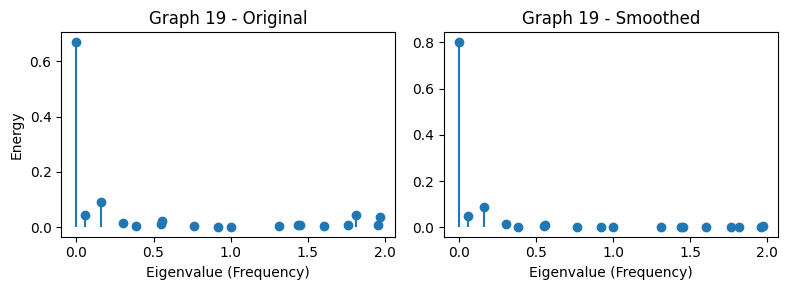

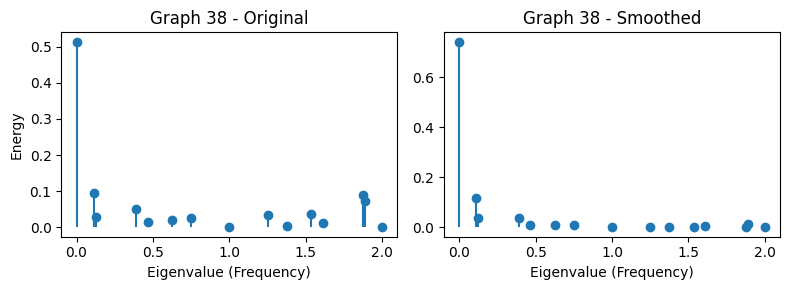

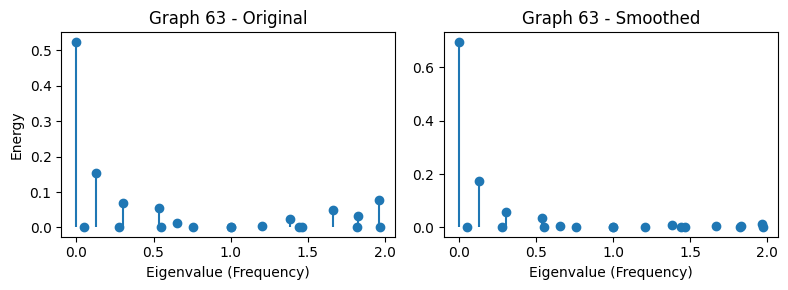

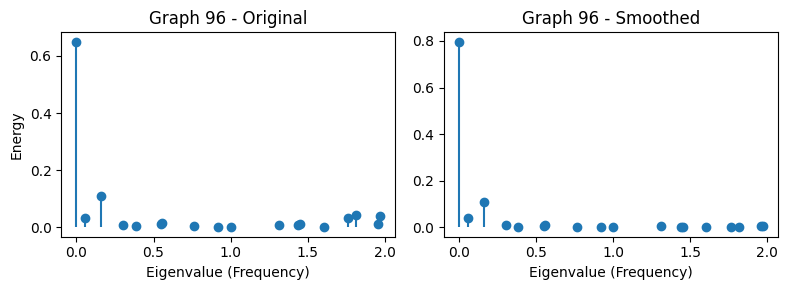

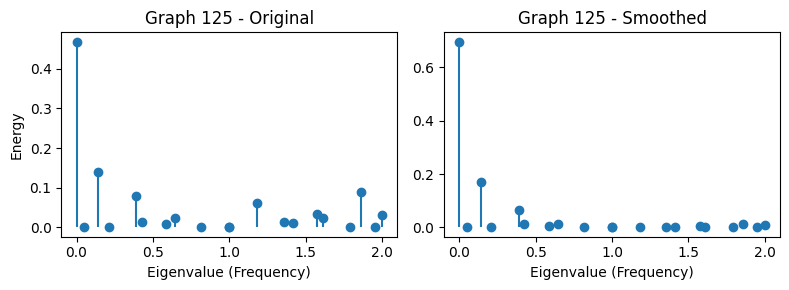

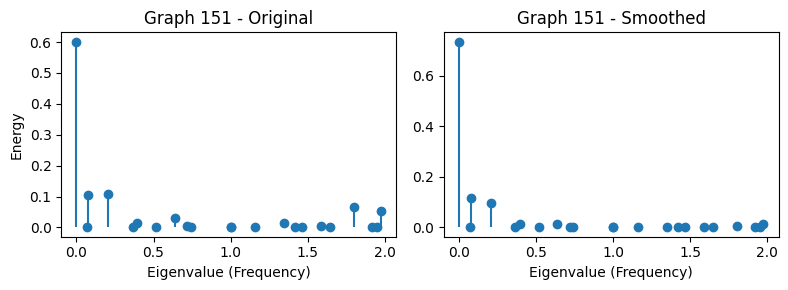


Mean low-frequency energy fraction (first 5 components):
Original: 0.7992 ± 0.0800
Smoothed: 0.9504 ± 0.0288


In [28]:
# Graph Fourier Transform (GFT) analysis
def graph_laplacian(edge_index, num_nodes, normalized=True):
    A = to_dense_adj(edge_index, max_num_nodes=num_nodes)[0].numpy()
    if normalized:
        deg = A.sum(axis=1)
        with np.errstate(divide='ignore'):
            d_inv_sqrt = np.where(deg > 0, 1.0 / np.sqrt(deg), 0.0)
        D_inv_sqrt = np.diag(d_inv_sqrt)
        L = np.eye(num_nodes) - D_inv_sqrt @ A @ D_inv_sqrt
    else:
        D = np.diag(A.sum(axis=1))
        L = D - A
    return L

def compute_gft_energy(data):
    x = data.x.cpu().numpy()
    L = graph_laplacian(data.edge_index, data.num_nodes, normalized=True)
    evals, evecs = np.linalg.eigh(L)
    coeffs = evecs.T @ x
    energy = np.sum(coeffs**2, axis=1)
    energy = energy / (np.sum(energy) + 1e-12)
    return evals, energy

# Pick a few sample graphs for plotting
sample_idxs = [19, 38, 63, 96, 125, 151]
for idx in sample_idxs:
    evals_o, energy_o = compute_gft_energy(dataset[idx])
    evals_s, energy_s = compute_gft_energy(smoothed_dataset[idx])

    plt.figure(figsize=(8, 3))
    plt.subplot(1, 2, 1)
    plt.stem(evals_o, energy_o, basefmt=" ")
    plt.title(f"Graph {idx} - Original")
    plt.xlabel("Eigenvalue (Frequency)")
    plt.ylabel("Energy")

    plt.subplot(1, 2, 2)
    plt.stem(evals_s, energy_s, basefmt=" ")
    plt.title(f"Graph {idx} - Smoothed")
    plt.xlabel("Eigenvalue (Frequency)")

    plt.tight_layout()
    plt.show()

# Compute low-frequency energy fraction over multiple graphs
def low_freq_fraction(energy, k=5):
    return np.sum(energy[:k])

fractions_orig = []
fractions_smooth = []
for idx in range(20, 120, 2):  # Sample different graphs
    _, e_o = compute_gft_energy(dataset[idx])
    _, e_s = compute_gft_energy(smoothed_dataset[idx])
    fractions_orig.append(low_freq_fraction(e_o))
    fractions_smooth.append(low_freq_fraction(e_s))

print(f"\nMean low-frequency energy fraction (first 5 components):")
print(f"Original: {np.mean(fractions_orig):.4f} ± {np.std(fractions_orig):.4f}")
print(f"Smoothed: {np.mean(fractions_smooth):.4f} ± {np.std(fractions_smooth):.4f}")
